In [26]:
import pandas as pd
import ast
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("../data/movies_1990_2026.csv")

In [17]:
df.sample(10)

,id,title,year,description,genres,rating,num_votes,adult
1068,10443,Fearless,1993,After surviving a plane crash that kills many ...,['Drama'],6.911,338,False
6052,20662,Robin Hood,2010,When soldier Robin happens upon the dying Robe...,"['Action', 'Adventure', 'History', 'Drama']",6.396,5004,False
9085,641167,Men at Work: Miami,2020,When charismatic stripper Jorrit is single aga...,"['Comedy', 'Music']",5.200,15,False
8992,643236,Meet the Malawas,2019,"A news anchor, a comedian, an actress, and a s...",['Comedy'],4.445,190,False
7311,204922,Before I Go to Sleep,2014,"A woman wakes up every day, remembering nothin...","['Thriller', 'Mystery']",6.490,2137,True
3264,36047,The In Crowd,2000,A mentally disturbed young woman takes a job a...,"['Drama', 'Mystery', 'Thriller']",4.700,60,True
9240,489326,Mortal,2020,A young boy must discover the origins of his e...,"['Action', 'Fantasy', 'Thriller']",6.470,506,True
8754,458723,Us,2019,Husband and wife Gabe and Adelaide Wilson take...,"['Horror', 'Mystery']",6.900,8037,True
8200,464733,Trafficked,2017,"In this story inspired by real characters, thr...",['Drama'],6.600,95,False
8344,363126,Berlin Syndrome,2017,A passionate holiday romance leads to an obses...,"['Drama', 'Horror', 'Mystery', 'Thriller']",6.033,691,True


In [18]:
df.shape

(11100, 8)

In [19]:
df.describe()

,id,year,rating,num_votes
count,1.110000e+04,11100.000000,11100.000000,11100.000000
mean,2.844429e+05,2008.000000,6.344302,1646.712072
std,3.850381e+05,10.677559,1.234313,3238.196017
min,5.000000e+00,1990.000000,0.000000,0.000000
25%,1.324900e+04,1999.000000,5.892000,91.000000
50%,7.073800e+04,2008.000000,6.492000,477.000000
75%,4.474928e+05,2017.000000,7.068000,1673.250000
max,1.693346e+06,2026.000000,10.000000,39702.000000


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11100 entries, 0 to 11099
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           11100 non-null  int64  
 1   title        11100 non-null  object 
 2   year         11100 non-null  int64  
 3   description  11045 non-null  object 
 4   genres       11100 non-null  object 
 5   rating       11100 non-null  float64
 6   num_votes    11100 non-null  int64  
 7   adult        11100 non-null  bool   
dtypes: bool(1), float64(1), int64(3), object(3)
memory usage: 618.0+ KB


In [21]:
df[df["adult"] == True]

,id,title,year,description,genres,rating,num_votes,adult
0,769,GoodFellas,1990,"The true story of Henry Hill, a half-Irish, ha...","['Drama', 'Crime']",8.453,14303,True
3,242,The Godfather Part III,1990,In the midst of trying to legitimize his busin...,"['Crime', 'Drama', 'Thriller']",7.419,6836,True
5,60898,Erotic Ghost Story,1990,"After one thousand years, three vixens transfo...","['Fantasy', 'Drama', 'Horror']",6.200,94,True
6,251,Ghost,1990,"After a young man is murdered, his spirit stay...","['Fantasy', 'Romance', 'Thriller']",7.233,6003,True
10,1700,Misery,1990,"After an accident, acclaimed novelist Paul She...","['Drama', 'Thriller']",7.747,5212,True
...,...,...,...,...,...,...,...,...
11090,1652401,Scissors,2026,Follows a slasher with a grudge who meets his ...,"['Horror', 'Comedy']",10.000,1,True
11091,1227877,I Love Boosters,2026,A fearless crew of inventive young women turn ...,"['Comedy', 'Science Fiction', 'Crime']",0.000,0,True
11092,1610901,Aag Lagay Basti Mein,2026,"Barkat is an honest, hard-working man struggli...","['Action', 'Crime', 'Comedy']",0.000,0,True
11094,1291595,Insidious: Out of the Further,2026,A trio of stalkers infiltrate a quiet suburb a...,"['Horror', 'Thriller']",0.000,0,True


In [22]:
df["genres"].dtype

dtype('O')

In [23]:
df['genres_parsed'] = df['genres'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) and str(x).strip() else []
)

all_genres = df['genres_parsed'].explode()

genre_counts = all_genres.value_counts()

In [44]:
genres_list = genre_counts.index.tolist()
counts_list = genre_counts.tolist()

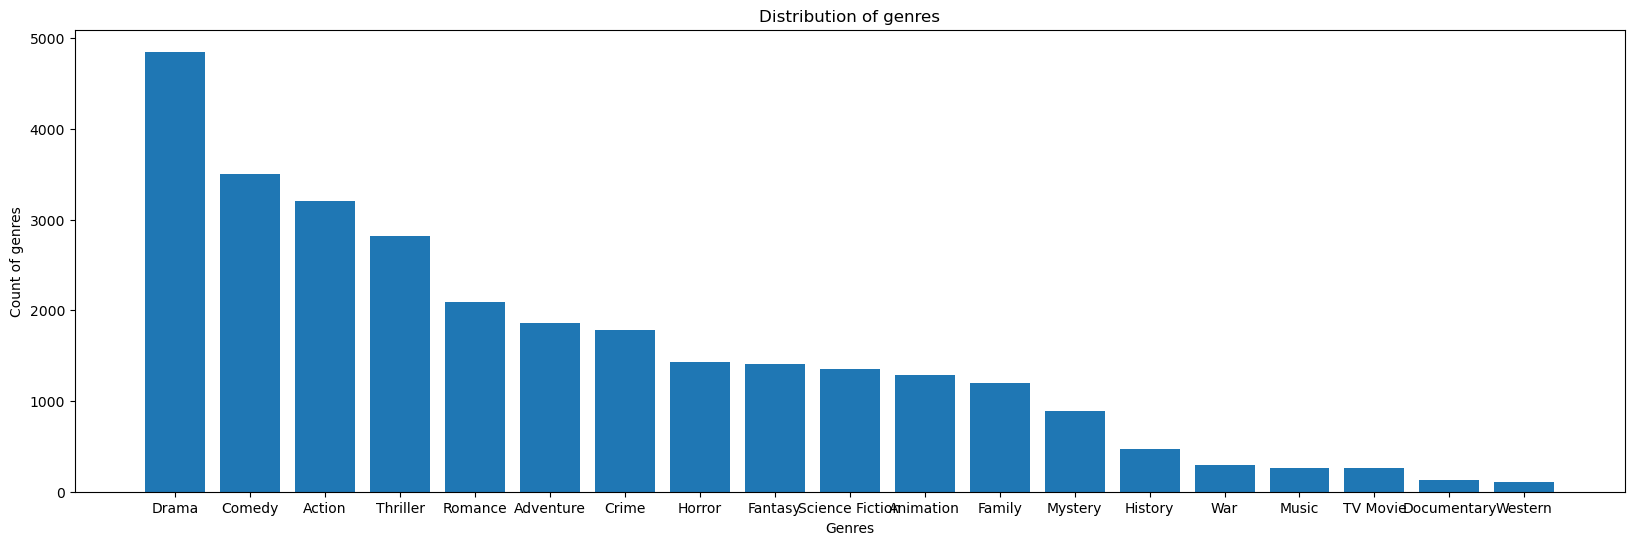

In [ ]:
plt.figure(figsize = (20, 6))
plt.bar(genres_list, counts_list)
plt.title("Distribution of genres")
plt.xlabel("Genres")
plt.ylabel("Count of genres")
plt.savefig("../artifacts/genres_distribution.png")